In [1]:
from pathlib import Path
import sys

def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    markers = ["README.md", ".git", "Models", "utils.py"]
    for d in [p] + list(p.parents):
        if any((d / m).exists() for m in markers):
            return d
    return p

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from functools import partial
from utils import *
from Models.Generative_Closures.Generative_Models import *
from Models.Generative_Closures.Interpolant import *
from Models.Pretrained_Autoencoders.AE import *
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
plt.rc("text", usetex=True)
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

In [3]:
# Check if CUDA is available
if torch.cuda.is_available():
    print("CUDA is available.")
    device = torch.device('cuda')
else:
    print("CUDA is not available.")
    device = torch.device('cpu')

# Load the data
DATA_PATH = ROOT / "Data" / "closure_sim_5steps20sec_subset.h5"

with h5py.File(DATA_PATH, 'r') as file:
    sol = torch.tensor(file['sol'], device=device)

metrics = ErrorMetrics()

CUDA is available.


Ground Truth Simulation To Match

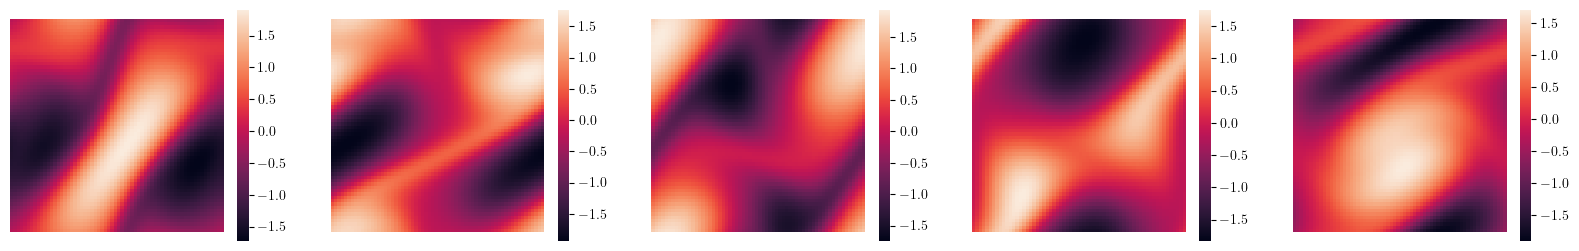

In [12]:
fig, axs = plt.subplots(1, 5, figsize=(20, 3))
for i in range(5):
    sns.heatmap(sol[0, :, :, i].cpu().numpy(), ax=axs[i], cbar=True, cmap="rocket", square=True)
    axs[i].axis("off")
plt.show()

For demo purpose, we present coarse simulations corrected with the jointly trained flow matching model.

In [19]:
# Viscosity parameter
nu = 1e-3

# Spatial Resolution
s = 64
# Forcing function: 0.1*(sin(2pi(x+y)) + cos(2pi(x+y)))
t = torch.linspace(0, 1, s + 1, device=device)
t = t[0:-1]

X, Y = torch.meshgrid(t, t)
f = 0.1 * (torch.sin(2 * math.pi * (X + Y)) + torch.cos(2 * math.pi * (X + Y)))

In [30]:
def navier_stokes_2d_nonlinear(a, w0, f, visc, simu_time, sampler, AEW, AEG, num_ensembles, closure = False, delta_t=1e-4, record_steps=1, eval_steps=10):
    # Grid size - must be power of 2
    N1, N2 = w0.size()[-2], w0.size()[-1]

    # Maximum frequency
    k_max = math.floor(N1 / 2.0)

    # Initial vorticity to Fourier space
    w_h = torch.fft.rfft2(w0)
    # Forcing to Fourier space
    f_h = torch.fft.rfft2(f)
    # If same forcing for the whole batch
    if len(f_h.size()) < len(w_h.size()):
        f_h = torch.unsqueeze(f_h, 0)

    # Wavenumbers in y-direction
    k_y = torch.cat((torch.arange(start=0, end=k_max, step=1, device=w0.device),
                     torch.arange(start=-k_max, end=0, step=1, device=w0.device)), 0).repeat(N1, 1)
    # Wavenumbers in x-direction
    k_x = k_y.transpose(0, 1)

    # Truncate redundant modes
    k_x = k_x[..., :k_max + 1]
    k_y = k_y[..., :k_max + 1]

    # Physical wavenumbers
    kx_2d = 2.0 * torch.pi * k_x / a[0]
    ky_2d = 2.0 * torch.pi * k_y / a[1]

    # Negative Laplacian in Fourier space
    lap = kx_2d ** 2 + ky_2d ** 2
    lap[0, 0] = 1.0

    sol = torch.zeros(*w0.size(), record_steps+1, device=w0.device)
    sol_t = torch.zeros(record_steps+1, device=w0.device)

    total_steps = int(simu_time / delta_t)
    record_steps_thres = int(total_steps / record_steps)
    t = 0.0

    start_time = time.time()
    for i in tqdm(range(total_steps)):
        w = torch.fft.irfft2(w_h, s=(N1, N2))

        if closure == True:
            if i % eval_steps == 0:
                if AEW != None:
                    with torch.no_grad():
                        w_cond = AEW.encode(w)
                else:
                    w_cond = w
                nonlinear_sample = sampler(omega=w_cond).reshape(-1, w_cond.shape[1], w_cond.shape[2])
                if AEG != None:
                    with torch.no_grad():
                        nonlinear_sample = AEG.decode(nonlinear_sample)
            else:
                nonlinear_sample = nonlinear_sample + torch.randn_like(nonlinear_sample) * 0.00005

            # convection term
            nonlinear_h = torch.fft.rfft2(nonlinear_sample)

            w_h = ((w_h  + delta_t * f_h + delta_t * nonlinear_h
                            - 0.5 * delta_t * visc * lap * w_h)
                           / (1.0 + 0.5 * delta_t * visc * lap))

        if closure == False:
            w_h = ((w_h  + delta_t * f_h
                            - 0.5 * delta_t * visc * lap * w_h)
                           / (1.0 + 0.5 * delta_t * visc * lap))
        if i == 0:
            sol[..., 0] = w
            sol_t[0] = t
        if (i+1) % record_steps_thres == 0:
            j = int((i + 1) / record_steps_thres)
            sol[..., j] = w
            sol_t[j] = t
        t += delta_t
    end_time = time.time()

    execution_time = end_time - start_time
    return sol, sol_t, execution_time

In [23]:
def sample_closure_field(
    method: str,
    model: torch.nn.Module,
    omega: torch.Tensor,
    num_ensembles: int = 1,
    sample_steps: int = 100,
    sigma_coef: float = 1.0,
    time_min: float = 1e-3,
    time_max: float = 1.0,
    time_schedule: str = 'uniform',   # 'uniform' or 'karras'
    return_starting_field: bool = False,
    device: str = 'cuda',
):
    """
    Unified closure sampler for 'diffusion', 'onesided', and 'twosided' methods.
    - 'DM'  : standard score-based SDE sampler
    - 'FM'   : flow matching sampler
    - 'SI_known' : stochastic interpolant sampler with known base dist
    - 'SI_gaussian' : stochastic interpolant sampler with gaussian base dist

    Returns:
        Tensor of shape (B, num_ensembles, H, W).  If return_starting_field=True,
    """
    B, H, W = omega.shape
    omega = omega.to(device)
    model = model.to(device)
    model.eval()

    # 1) Build the time grid ts = [time_max, ..., time_min]
    if time_schedule == 'uniform':
        ts = torch.linspace(time_max, time_min, sample_steps+1, device=device)
        ts_forward = torch.linspace(time_min, time_max, sample_steps+1, device=device)
    elif time_schedule == 'karras':
        ts = get_sigmas_karras(sample_steps, time_min, time_max, device=device)
        ts_forward = reversed(ts)
    else:
        raise ValueError(f"Unknown time_schedule: {time_schedule}")
    dt = ts[:-1] - ts[1:]  # step sizes for Euler integration
    dt_forward = ts_forward[1:] - ts_forward[:-1]

    # 2) Tile conditioning omega to match ensemble dimension
    omega_rep = omega.unsqueeze(1).repeat(1, num_ensembles, 1, 1).view(-1, H, W)

    if method == 'DM':
        marginal_prob_std_fn = partial(marginal_prob_std, sigma=sigma_coef, device_=device)
        diffusion_coeff_fn = partial(diffusion_coeff, sigma=sigma_coef, device_=device)
        # 3) Initialize x at t = ts[0] ~ N(0, [marginal std]^2)
        t0 = ts[0].repeat(B * num_ensembles)
        x = torch.randn_like(omega_rep) * marginal_prob_std_fn(t0)[:, None, None]
        x0 = x.clone()  # store initial noise if requested

        total_distance = torch.zeros(B * num_ensembles, device=device)
        x_prev = x.clone()


        with torch.no_grad():
            for i in range(sample_steps):
                t_i = ts[i].repeat(B * num_ensembles)
                step_size = dt[i]

                g = diffusion_coeff_fn(t_i)        # shape [B*num_ensembles]
                grad = model(t_i, x, omega_rep)    # score: [B*num_ensembles, H, W]

                # Euler–Maruyama update:
                mean = x + (g**2)[:, None, None] * grad * step_size
                if i < sample_steps - 1:
                    noise = torch.randn_like(x)
                    x = mean + math.sqrt(step_size) * g[:, None, None] * noise
                else:
                    x = mean # no extra noise on final step

                dist = torch.sqrt(torch.sum((x - x_prev)**2, dim=(1,2)))
                total_distance += dist

                # prepare for next iteration
                x_prev.copy_(x)

        x = x.view(B, num_ensembles, H, W)
        total_distance = total_distance.view(B, num_ensembles)
        if return_starting_field:
            x0 = x0.view(B, num_ensembles, H, W)
            return x0, x, total_distance
        else:
            return x

    elif method == 'SI_known':
        # 3) Initialize X_t at t=ts[0]=1 as x1 = omega_rep
        Xt = omega_rep.clone()
        X0 = Xt.clone()  # store if requested


        total_distance = torch.zeros(B * num_ensembles, device=device)
        x_prev = Xt.clone()

        with torch.no_grad():
            for i in range(sample_steps):
                t = ts_forward[i]                                  # scalar in [0,1]
                step_size = dt_forward[i]                          # > 0
                t_batch = t.repeat(B * num_ensembles).to(device)
                drift = model(t_batch, Xt, omega_rep)      # [B*num_ensembles, H, W]
                gdot_scalar = 1 - t
                gdot = gdot_scalar.repeat(B * num_ensembles)
                gdot = gdot.view([B * num_ensembles] + [1] * (Xt.ndim - 1))

                # 4.3) Euler–Maruyama backward step (no sign flip: dt>0, but X_{t-dt}=X_t - drift*dt + ...)
                if i < sample_steps - 1:
                    noise = torch.randn_like(Xt)
                    # Xt = Xt + drift * step_size
                    Xt = Xt + drift * step_size + gdot * math.sqrt(step_size) * noise
                else:
                    Xt = Xt + drift * step_size

                dist = torch.sqrt(torch.sum((Xt - x_prev)**2, dim=(1,2)))
                total_distance += dist

                # prepare for next iteration
                x_prev.copy_(Xt)

        Xt = Xt.view(B, num_ensembles, H, W)
        total_distance = total_distance.view(B, num_ensembles)
        if return_starting_field:
            X0 = X0.view(B, num_ensembles, H, W)
            return X0, Xt, total_distance
        else:
            return Xt


    elif method == 'SI_gaussian':
        # 3) Initialize X_t at t=ts[0]=1 as x1 = omega_rep
        Xt = torch.randn_like(omega_rep)
        X0 = Xt.clone()  # store if requested

        total_distance = torch.zeros(B * num_ensembles, device=device)
        x_prev = Xt.clone()

        with torch.no_grad():
            for i in range(sample_steps):
                t = ts_forward[i]                                  # scalar in [0,1]
                step_size = dt_forward[i]                          # > 0
                t_batch = t.repeat(B * num_ensembles).to(device)
                drift = model(t_batch, Xt, omega_rep)      # [B*num_ensembles, H, W]
                gdot_scalar = 1 - t
                gdot = gdot_scalar.repeat(B * num_ensembles)
                gdot = gdot.view([B * num_ensembles] + [1] * (Xt.ndim - 1))

                # 4.3) Euler–Maruyama backward step (no sign flip: dt>0, but X_{t-dt}=X_t - drift*dt + ...)
                if i < sample_steps - 1:
                    noise = torch.randn_like(Xt)
                    Xt = Xt + drift * step_size + gdot * math.sqrt(step_size) * noise
                else:
                    Xt = Xt + drift * step_size

                dist = torch.sqrt(torch.sum((Xt - x_prev)**2, dim=(1,2)))
                total_distance += dist

                # prepare for next iteration
                x_prev.copy_(Xt)

        Xt = Xt.view(B, num_ensembles, H, W)
        total_distance = total_distance.view(B, num_ensembles)
        if return_starting_field:
            X0 = X0.view(B, num_ensembles, H, W)
            return X0, Xt, total_distance
        else:
            return Xt

    elif method == 'FM':
        # 3) Initialize X_t at t=ts[0]=1 as x1 = omega_rep
        Xt = torch.randn_like(omega_rep)
        X0 = Xt.clone()  # store if requested
        total_distance = torch.zeros(B * num_ensembles, device=device)
        x_prev = Xt.clone()
        with torch.no_grad():
            for i in range(sample_steps):
                t = ts_forward[i]                                  # scalar in [0,1]
                step_size = dt_forward[i]                          # > 0
                t_batch = t.repeat(B * num_ensembles).to(device)
                drift = model(t_batch, Xt, omega_rep)      # [B*num_ensembles, H, W]
                Xt = Xt + drift * step_size

                dist = torch.sqrt(torch.sum((Xt - x_prev)**2, dim=(1,2)))
                total_distance += dist

                # prepare for next iteration
                x_prev.copy_(Xt)
        Xt = Xt.view(B, num_ensembles, H, W)
        total_distance = total_distance.view(B, num_ensembles)
        if return_starting_field:
            X0 = X0.view(B, num_ensembles, H, W)
            return X0, Xt, total_distance
        else:
            return Xt

    else:
        raise ValueError(f"Unknown sampling method: {method}")


In [24]:
nonlinear_AE = VariationalAutoEncoder().to(device)
vorticity_AE = VariationalAutoEncoder().to(device)
NONLINEAR_AE_PATH = ROOT / "Trained_Models" / "AE" / "Nonlinear" / "Joint_AE_Nonlinear_FM.pth"
VORTICITY_AE_PATH = ROOT / "Trained_Models" / "AE" / "Vorticity" / "Joint_AE_Vorticity_FM.pth"
nonlinear_AE.load_state_dict(torch.load(NONLINEAR_AE_PATH))
vorticity_AE.load_state_dict(torch.load(VORTICITY_AE_PATH))

<All keys matched successfully>

In [25]:
set_seed(42)
num_ensembles = 1

modes = 4
width = 20
Latent_FM = FNO2d_Orig(modes, modes, width, padding = 0, embed_dim = 256, length = 1).to(device)

model_name = ROOT / "Trained_Models" / "FM" / "Latent_FM" / "Joint_FM.pth"
Latent_FM.load_state_dict(torch.load(model_name))

Random seed set as 42


<All keys matched successfully>

In [34]:
sol_start = sol[..., 0]

latent_sampler = partial(sample_closure_field, method='FM', model=Latent_FM, num_ensembles=num_ensembles, sample_steps=10, sigma_coef=1.0, time_min=1e-3, time_max=1.0, time_schedule='uniform', device=device)

sol_latent_closure, sol_t_latent_closure, exec_time_latent_closure = navier_stokes_2d_nonlinear(
    a=[1.0, 1.0],
    w0=sol_start,
    f=f,
    visc=nu,
    simu_time=20.0,
    sampler=latent_sampler,
    AEW=vorticity_AE,
    AEG=nonlinear_AE,
    num_ensembles=num_ensembles,
    closure=True,
    delta_t=1e-3, record_steps=4, eval_steps=5
)


100%|██████████| 20000/20000 [02:12<00:00, 151.35it/s]


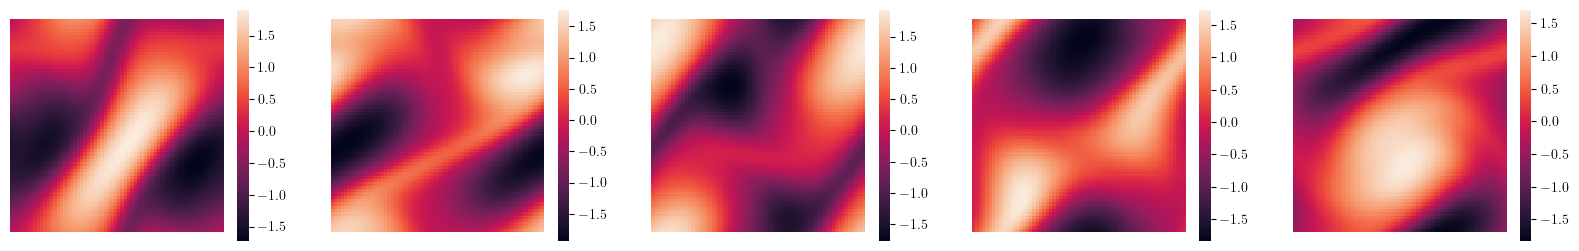

In [35]:
fig, axs = plt.subplots(1, 5, figsize=(20, 3))
for i in range(5):
    sns.heatmap(sol_latent_closure[0, :, :, i].cpu().numpy(), ax=axs[i], cbar=True, cmap="rocket", square=True)
    axs[i].axis("off")
plt.show()